# Lesson 1 — Setting Up

*ESP2110 Inverted Pendulum Lab*

**Run in Google Colab:** open the notebook, run the **Setup** cell once, then run
cells top-to-bottom. No local files are required.

## Learning objectives
By the end of this notebook you can:
1. Describe the **inverted-pendulum task**, the **state variables**, and the sign conventions used all lab.
2. Simulate the **open-loop** cart-pole and see that the upright pole **falls on its own**.
3. Probe the plant as a **black box** — apply force pulses and see how the cart and pole respond.
4. Identify **which parameters dominate** the behaviour.

### Parameters (same plant used throughout the lab)
| Symbol | Meaning | Value |
| --- | --- | --- |
| `m_c` | Cart mass | 0.5 kg |
| `m_p` | Pole mass | 0.2 kg |
| `L` | Pole length | 0.3 m |
| `g` | Gravity | 9.81 m/s^2 |
| `dt` | Sample time | 0.01 s |

In [1]:
# --- Setup (safe to re-run) ---
try:
    import numpy, scipy, matplotlib  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'numpy', 'scipy', 'matplotlib'], check=True)
print('Environment ready.')

Environment ready.


---
## The task

A pole is attached by a free (un-actuated) hinge to a cart that slides on a horizontal track.
The **only** thing you can do is push the cart left/right with a force `f`. Gravity constantly
tries to topple the pole. The goal of the whole lab is to design that force so the pole stays
**upright**.

### State variables
We track four numbers, `x = [p, v, theta, omega]`:

| Symbol | Meaning | Sign convention |
| --- | --- | --- |
| `p` | cart position (m) | + to the right |
| `v` | cart velocity (m/s) | + to the right |
| `theta` | pole angle (rad) | **0 = straight up**, + tilts right |
| `omega` | pole angular velocity (rad/s) | + tilts right |

The single input is the force `f` (N) on the cart. This lesson only *observes* the plant —
control comes later (Lessons 4A onward).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

m_c, m_p, L, g, dt = 0.5, 0.2, 0.3, 9.81, 0.01

def f_nonlin(s, f):
    """Full nonlinear cart-pole derivative. State s = [p, v, theta, omega]; theta=0 is upright."""
    p, v, th, om = s
    sin, cos = np.sin(th), np.cos(th)
    den = m_c + m_p * sin**2
    vdot  = (f + m_p * sin * (L * om**2 - g * cos)) / den
    omdot = (-f * cos - m_p * L * om**2 * sin * cos + (m_c + m_p) * g * sin) / (L * den)
    return np.array([v, vdot, om, omdot])

def simulate(force_fn, x0, T=2.0):
    """Euler-integrate the nonlinear plant. force_fn(k, x) -> applied force at step k."""
    n = int(T / dt); x = np.array(x0, dtype=float)
    X = np.zeros((n, 4)); F = np.zeros(n)
    for k in range(n):
        f = force_fn(k, x); F[k] = f; X[k] = x
        x = x + dt * f_nonlin(x, f)
    return np.arange(n) * dt, X, F

## Part 1 - Let go and watch it fall

Set the force to zero, start the pole just slightly off-upright (`theta0 = 0.05 rad ~ 3 deg`),
and simulate. With no control, the upright equilibrium is unstable — the pole should topple.

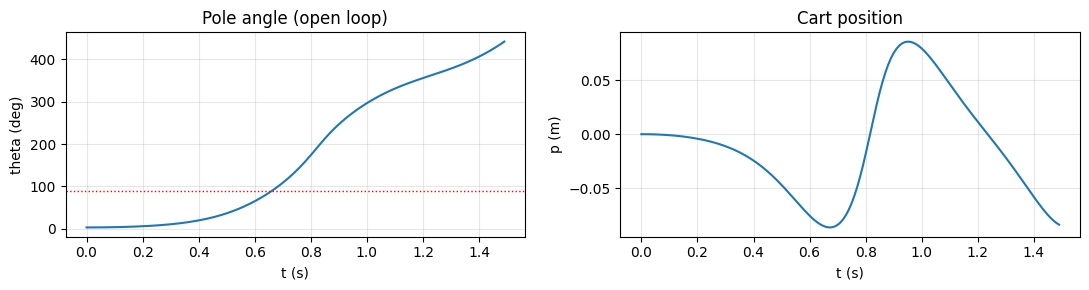

Pole passes 90 deg at t = 0.67 s


In [3]:
t, X, F = simulate(lambda k, x: 0.0, x0=[0, 0, 0.05, 0.0], T=1.5)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, np.degrees(X[:, 2])); ax[0].axhline(90, color='r', ls=':', lw=1)
ax[0].set(title='Pole angle (open loop)', xlabel='t (s)', ylabel='theta (deg)'); ax[0].grid(alpha=.3)
ax[1].plot(t, X[:, 0]); ax[1].set(title='Cart position', xlabel='t (s)', ylabel='p (m)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
fell = t[np.argmax(np.abs(X[:, 2]) > np.pi/2)]
print('Pole passes 90 deg at t =', round(fell, 2), 's')

**Expected output.** The pole angle grows and **passes 90 deg at about t = 0.67 s** — it falls
over by itself. The cart also drifts. This instability is exactly what every later lesson fights.

## Part 2 - Poke it: the black-box response

Treat the plant as a black box. Apply a short force **pulse** (push right for 0.2 s) starting
from rest at upright, and watch how the cart and pole react.

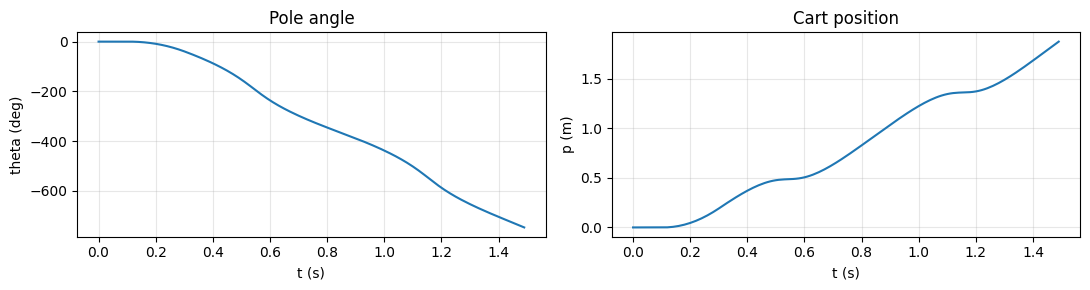

In [4]:
def pulse(k, x):
    return 5.0 if 10 <= k < 30 else 0.0   # 5 N for steps 10..29 (0.1 s..0.3 s)

t, X, F = simulate(pulse, x0=[0, 0, 0.0, 0.0], T=1.5)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, np.degrees(X[:, 2])); ax[0].set(title='Pole angle', xlabel='t (s)', ylabel='theta (deg)'); ax[0].grid(alpha=.3)
ax[1].plot(t, X[:, 0]); ax[1].set(title='Cart position', xlabel='t (s)', ylabel='p (m)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Expected output.** Pushing the cart right kicks the pole the *opposite* way (it tips left),
and once disturbed the pole keeps falling — a brief push is enough to lose it. Notice the
counter-intuitive coupling: to catch a pole tipping right you must drive the cart right (you
will exploit this sign in Lesson 4A).

## Part 3 - Which parameters matter?

Change one physical parameter at a time and see how fast the pole falls from the same small
angle. This builds intuition for what the controller is up against.

In [5]:
import numpy as _np
def fall_time(mc=m_c, mp=m_p, Lp=L, th0=0.05):
    x = _np.array([0, 0, th0, 0.0])
    for k in range(2000):
        p, v, th, om = x
        sin, cos = _np.sin(th), _np.cos(th); den = mc + mp * sin**2
        vd = (mp * sin * (Lp * om**2 - g * cos)) / den
        od = (-mp * Lp * om**2 * sin * cos + (mc + mp) * g * sin) / (Lp * den)
        x = x + dt * _np.array([v, vd, om, od])
        if abs(x[2]) > _np.pi/2:
            return k * dt
    return None

print('baseline           :', fall_time(), 's')
print('heavier cart (2x)  :', fall_time(mc=1.0), 's')
print('longer pole (2x)   :', fall_time(Lp=0.6), 's')
print('heavier pole (2x)  :', fall_time(mp=0.4), 's')

baseline           : 0.66 s
heavier cart (2x)  : 0.7000000000000001 s
longer pole (2x)   : 0.92 s
heavier pole (2x)  : 0.6 s


**Expected output.** A **longer pole falls noticeably slower** (more rotational inertia — the
fall time roughly tracks sqrt(L)), while cart and pole *mass* changes barely move the fall time
for the unforced pole. Longer poles are genuinely easier to balance — which is why balancing a
broom is easier than balancing a pencil.

## Part 4 - Watch it fall (animation)

A quick cart-pole animation of the open-loop fall, so you have a visual to carry through the lab.

In [6]:
from matplotlib import animation
from IPython.display import HTML

t, X, F = simulate(lambda k, x: 0.0, x0=[0, 0, 0.05, 0.0], T=1.2)
frames = np.arange(0, len(X), 4)
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_xlim(-0.6, 0.6); ax.set_ylim(-0.35, 0.35); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('Open-loop: the pole falls'); ax.set_xlabel('x (m)')
cart = plt.Rectangle((-0.12, -0.06), 0.24, 0.12, fc='steelblue', ec='k'); ax.add_patch(cart)
pole, = ax.plot([], [], lw=3, color='crimson')
bob,  = ax.plot([], [], 'o', color='crimson', ms=9)

def _u(j):
    i = frames[j]; p, th = X[i, 0], X[i, 2]
    cart.set_xy((p - 0.12, -0.06))
    tx, ty = p + L * np.sin(th), 0.06 + L * np.cos(th)
    pole.set_data([p, tx], [0.06, ty]); bob.set_data([tx], [ty])
    ax.set_xlim(p - 0.6, p + 0.6)
    return cart, pole, bob

anim = animation.FuncAnimation(fig, _u, frames=len(frames), interval=60, blit=False)
plt.close(fig); HTML(anim.to_jshtml())

---
## Checkpoints
- The open-loop pole falls past 90 deg in well under a second (~0.66 s from 3 deg).
- A brief force pulse permanently disturbs the pole — open loop, it never recovers.
- A longer pole falls more slowly; mass changes matter much less for the unforced fall.
- You can describe the four state variables and the sign of each.

## Common pitfalls
- **Angle units.** `theta` is in **radians** internally; convert to degrees only for plotting.
- **Wrong equilibrium.** `theta = 0` is **upright** here (not hanging down). Start near 0 to study balancing.
- **Euler step too large.** `dt = 0.01` is fine; much larger and Euler integration becomes inaccurate or unstable.
- **Reading the sign backwards.** Pushing the cart one way tips the pole the other way — keep the conventions straight.